In [1]:
import sys
print(f"Python: {sys.version}")

# 핵심 라이브러리 버전 확인
libs = ['numpy', 'scipy', 'pandas', 'matplotlib', 'networkx', 'sklearn']
for lib in libs:
    try:
        mod = __import__(lib)
        print(f"{lib}: {mod.__version__}")
    except ImportError:
        print(f"{lib}: NOT INSTALLED")
    except AttributeError:
        print(f"{lib}: installed (version unknown)")

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0]
numpy: 2.2.5
scipy: 1.15.3
pandas: 2.2.3
matplotlib: 3.10.0
networkx: 3.3
sklearn: 1.6.1


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)  # 재현성

# 토이 데이터: 2개 그룹의 학생들이 4개 주제로 토론
# Group A: "데이터" 중심 사고
# Group B: "이론" 중심 사고
# 같은 코드들이 다른 패턴으로 나타나야 ENA가 의미있음

codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']

def generate_utterances(unit_id, group, n_turns=20):
    rows = []
    for turn in range(n_turns):
        row = {
            'unit': unit_id,
            'group': group,
            'conversation': f"{group}_session1",
            'turn': turn,
        }
        # 그룹별로 코드 확률 다르게
        if group == 'A':
            probs = {'Data': 0.6, 'Theory': 0.2, 'Question': 0.4, 
                     'Example': 0.5, 'Critique': 0.3}
        else:
            probs = {'Data': 0.2, 'Theory': 0.6, 'Question': 0.4, 
                     'Example': 0.3, 'Critique': 0.5}
        for code in codes:
            row[code] = int(np.random.random() < probs[code])
        rows.append(row)
    return rows

# 6명: A그룹 3명, B그룹 3명
all_rows = []
for i in range(1, 4):
    all_rows.extend(generate_utterances(f"A{i}", 'A'))
for i in range(1, 4):
    all_rows.extend(generate_utterances(f"B{i}", 'B'))

df = pd.DataFrame(all_rows)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nUnits: {df['unit'].unique()}")
print(f"\nCode counts by group:")
print(df.groupby('group')[codes].sum())

Shape: (120, 9)
Columns: ['unit', 'group', 'conversation', 'turn', 'Data', 'Theory', 'Question', 'Example', 'Critique']

First 5 rows:
  unit group conversation  turn  Data  Theory  Question  Example  Critique
0   A1     A   A_session1     0     1       0         0        0         1
1   A1     A   A_session1     1     1       1         0        0         0
2   A1     A   A_session1     2     1       0         0        1         1
3   A1     A   A_session1     3     1       0         0        1         1
4   A1     A   A_session1     4     0       1         1        1         0

Units: ['A1' 'A2' 'A3' 'B1' 'B2' 'B3']

Code counts by group:
       Data  Theory  Question  Example  Critique
group                                           
A        33      13        22       30        27
B        12      31        28       13        29


In [3]:
from itertools import combinations

def get_code_pairs(codes):
    """모든 코드 쌍을 정렬된 순서로 반환. (Data,Theory), (Data,Question), ..."""
    return list(combinations(codes, 2))

def adjacency_vector(utterances_df, codes, stanza_window=4):
    """
    한 unit의 utterance들로부터 adjacency vector를 계산.
    
    Parameters
    ----------
    utterances_df : DataFrame
        한 unit + 한 conversation의 utterance들. 코드 컬럼이 0/1
    codes : list of str
        코드 이름 리스트
    stanza_window : int
        같은 stanza로 묶을 window 크기 (현재 + 이전 stanza_window-1개)
    
    Returns
    -------
    av : np.ndarray
        길이 C(n,2)의 벡터. 각 원소는 코드 쌍의 co-occurrence 카운트
    pairs : list
        쌍의 순서 (해석용)
    """
    pairs = get_code_pairs(codes)
    pair_to_idx = {pair: i for i, pair in enumerate(pairs)}
    av = np.zeros(len(pairs))
    
    # 코드 매트릭스만 추출 (n_turns × n_codes)
    code_matrix = utterances_df[codes].values
    n_turns = len(code_matrix)
    
    for i in range(n_turns):
        # 현재 turn의 활성 코드들
        current_codes = [codes[j] for j in range(len(codes)) if code_matrix[i, j] == 1]
        if not current_codes:
            continue
        
        # stanza window: 현재 포함 직전 (stanza_window-1)개까지
        window_start = max(0, i - stanza_window + 1)
        window = code_matrix[window_start:i+1]  # 현재 포함
        
        # window 내 (현재 turn 제외한 이전 turns)의 코드들과 현재 turn 코드의 co-occurrence
        # 단, 현재 turn 안에서의 co-occurrence도 포함 (자기 turn 내 동시 등장)
        for prev_idx in range(len(window)):
            prev_codes = [codes[j] for j in range(len(codes)) if window[prev_idx, j] == 1]
            
            if prev_idx == len(window) - 1:
                # 현재 turn 내 코드 쌍 (자기 자신과는 안 됨)
                for c1, c2 in combinations(current_codes, 2):
                    pair = (c1, c2) if (c1, c2) in pair_to_idx else (c2, c1)
                    av[pair_to_idx[pair]] += 1
            else:
                # 이전 turn의 코드 × 현재 turn의 코드
                for c_prev in prev_codes:
                    for c_curr in current_codes:
                        if c_prev == c_curr:
                            continue
                        pair = (c_prev, c_curr) if (c_prev, c_curr) in pair_to_idx else (c_curr, c_prev)
                        av[pair_to_idx[pair]] += 1
    
    return av, pairs


# 테스트: A1 unit으로 시험
a1_data = df[df['unit'] == 'A1'].sort_values('turn').reset_index(drop=True)
print(f"A1 data shape: {a1_data.shape}")
print(f"A1 첫 5 turns의 코드:")
print(a1_data[codes].head())

av_a1, pairs = adjacency_vector(a1_data, codes, stanza_window=4)

print(f"\nA1의 adjacency vector:")
for pair, val in zip(pairs, av_a1):
    print(f"  {pair[0]:10s} ↔ {pair[1]:10s}: {val:.0f}")

print(f"\nVector shape: {av_a1.shape}")
print(f"Sum (총 연결 강도): {av_a1.sum():.0f}")

A1 data shape: (20, 9)
A1 첫 5 turns의 코드:
   Data  Theory  Question  Example  Critique
0     1       0         0        0         1
1     1       1         0        0         0
2     1       0         0        1         1
3     1       0         0        1         1
4     0       1         1        1         0

A1의 adjacency vector:
  Data       ↔ Theory    : 20
  Data       ↔ Question  : 21
  Data       ↔ Example   : 29
  Data       ↔ Critique  : 27
  Theory     ↔ Question  : 23
  Theory     ↔ Example   : 24
  Theory     ↔ Critique  : 21
  Question   ↔ Example   : 23
  Question   ↔ Critique  : 22
  Example    ↔ Critique  : 24

Vector shape: (10,)
Sum (총 연결 강도): 234


In [4]:
np.random.seed(42)

def generate_utterances_sparse(unit_id, group, n_turns=20):
    """확률을 낮춰서 코드가 sparse하게 나타나도록"""
    rows = []
    for turn in range(n_turns):
        row = {
            'unit': unit_id,
            'group': group,
            'conversation': f"{group}_session1",
            'turn': turn,
        }
        # 그룹별 코드 확률 — 훨씬 낮고 더 뚜렷한 차이
        if group == 'A':
            probs = {'Data': 0.5, 'Theory': 0.05, 'Question': 0.2, 
                     'Example': 0.4, 'Critique': 0.1}
        else:
            probs = {'Data': 0.05, 'Theory': 0.5, 'Question': 0.2, 
                     'Example': 0.1, 'Critique': 0.4}
        for code in codes:
            row[code] = int(np.random.random() < probs[code])
        rows.append(row)
    return rows

all_rows = []
for i in range(1, 4):
    all_rows.extend(generate_utterances_sparse(f"A{i}", 'A'))
for i in range(1, 4):
    all_rows.extend(generate_utterances_sparse(f"B{i}", 'B'))

df = pd.DataFrame(all_rows)

print(f"Shape: {df.shape}")
print(f"\nCode counts by group:")
print(df.groupby('group')[codes].sum())
print(f"\nA1 첫 10 turns의 코드:")
print(df[df['unit']=='A1'].head(10)[codes])

Shape: (120, 9)

Code counts by group:
       Data  Theory  Question  Example  Critique
group                                           
A        28       2        14       27         6
B         3      25        17        3        28

A1 첫 10 turns의 코드:
   Data  Theory  Question  Example  Critique
0     1       0         0        0         0
1     1       0         0        0         0
2     1       0         0        1         0
3     1       0         0        0         0
4     0       0         0        1         0
5     0       0         0        0         1
6     0       0         1        0         0
7     0       0         1        0         0
8     1       0         1        0         0
9     0       0         0        0         0


In [5]:
def compute_all_avs(df, codes, unit_col='unit', conversation_col='conversation', 
                   stanza_window=4):
    """
    모든 (unit, conversation) 조합에 대해 AV 계산.
    
    Returns
    -------
    avs_df : DataFrame
        행: unit, 열: 코드 쌍, 값: co-occurrence count
    """
    pairs = get_code_pairs(codes)
    pair_labels = [f"{p[0]}_{p[1]}" for p in pairs]
    
    results = []
    for unit_id in df[unit_col].unique():
        unit_data = df[df[unit_col] == unit_id].sort_values('turn').reset_index(drop=True)
        # 같은 unit이 여러 conversation에 걸칠 수 있지만 토이는 하나씩
        av, _ = adjacency_vector(unit_data, codes, stanza_window=stanza_window)
        
        row = {'unit': unit_id, 'group': unit_data['group'].iloc[0]}
        for label, val in zip(pair_labels, av):
            row[label] = val
        results.append(row)
    
    return pd.DataFrame(results)

avs_df = compute_all_avs(df, codes, stanza_window=4)

print("모든 unit의 Adjacency Vector:")
print(avs_df.to_string())

print(f"\nShape: {avs_df.shape}")

# 그룹별 평균 AV
print(f"\n그룹별 평균 AV:")
pair_cols = [c for c in avs_df.columns if c not in ['unit', 'group']]
print(avs_df.groupby('group')[pair_cols].mean().round(1).to_string())

모든 unit의 Adjacency Vector:
  unit group  Data_Theory  Data_Question  Data_Example  Data_Critique  Theory_Question  Theory_Example  Theory_Critique  Question_Example  Question_Critique  Example_Critique
0   A1     A          0.0           11.0          20.0            3.0              0.0             0.0              0.0              15.0                3.0               2.0
1   A2     A          4.0           17.0          41.0            7.0              1.0             3.0              1.0              18.0                3.0               6.0
2   A3     A          2.0            8.0          18.0            5.0              0.0             3.0              1.0              10.0                2.0               8.0
3   B1     B          1.0            3.0           0.0            5.0             19.0             0.0             24.0               0.0               31.0               0.0
4   B2     B          4.0            1.0           1.0            1.0             11.0            

In [6]:
def sphere_normalize(av):
    """벡터를 L2 norm으로 정규화. 영벡터면 그대로 반환."""
    norm = np.linalg.norm(av)
    if norm == 0:
        return av
    return av / norm

# 모든 unit에 적용
pair_cols = [c for c in avs_df.columns if c not in ['unit', 'group']]
av_matrix = avs_df[pair_cols].values  # (6, 10)

# 각 행(unit)별로 정규화
normalized_matrix = np.array([sphere_normalize(row) for row in av_matrix])

# DataFrame으로 다시 정리
normalized_df = pd.DataFrame(normalized_matrix, columns=pair_cols)
normalized_df.insert(0, 'unit', avs_df['unit'].values)
normalized_df.insert(1, 'group', avs_df['group'].values)

print("정규화된 Adjacency Vector (각 행의 L2 norm = 1):")
print(normalized_df.round(3).to_string())

print(f"\n검증 — 각 행의 norm (모두 1이어야 함):")
for i, row in enumerate(normalized_matrix):
    print(f"  {avs_df['unit'].iloc[i]}: {np.linalg.norm(row):.6f}")

print(f"\n그룹별 평균 (정규화 후):")
print(normalized_df.groupby('group')[pair_cols].mean().round(3).to_string())

정규화된 Adjacency Vector (각 행의 L2 norm = 1):
  unit group  Data_Theory  Data_Question  Data_Example  Data_Critique  Theory_Question  Theory_Example  Theory_Critique  Question_Example  Question_Critique  Example_Critique
0   A1     A        0.000          0.397         0.722          0.108            0.000           0.000            0.000             0.541              0.108             0.072
1   A2     A        0.081          0.346         0.834          0.142            0.020           0.061            0.020             0.366              0.061             0.122
2   A3     A        0.082          0.328         0.738          0.205            0.000           0.123            0.041             0.410              0.082             0.328
3   B1     B        0.023          0.068         0.000          0.114            0.432           0.000            0.546             0.000              0.705             0.000
4   B2     B        0.145          0.036         0.036          0.036            0.

In [8]:
# SVD: M = U @ diag(S) @ Vt
# normalized_matrix: (6 units, 10 pair dims)
M = normalized_matrix.copy()

# 중심화 (centering) — ENA 표준 전처리
# 각 차원(코드 쌍)의 평균을 0으로
M_centered = M - M.mean(axis=0)

print(f"Centered matrix shape: {M_centered.shape}")
print(f"각 컬럼의 평균 (centering 후, 모두 ~0이어야 함):")
print(M_centered.mean(axis=0).round(6))

# SVD
U, S, Vt = np.linalg.svd(M_centered, full_matrices=False)

print(f"\nSVD 결과:")
print(f"  U shape: {U.shape}  (units × components)")
print(f"  S (singular values): {S.round(4)}")
print(f"  Vt shape: {Vt.shape}  (components × pair_dims)")

# 각 주성분이 설명하는 분산 비율
explained_variance = S**2 / (S**2).sum()
print(f"\n각 주성분의 설명 분산 비율:")
for i, ev in enumerate(explained_variance):
    print(f"  PC{i+1}: {ev*100:.2f}%")
print(f"  PC1+PC2 누적: {explained_variance[:2].sum()*100:.2f}%")

# 2D 공간으로 투영: 각 unit의 좌표
points_2d = M_centered @ Vt[:2].T  # (6 units, 2 dims)

# 결과 정리
result_df = pd.DataFrame({
    'unit': avs_df['unit'].values,
    'group': avs_df['group'].values,
    'x': points_2d[:, 0],
    'y': points_2d[:, 1]
})

print(f"\n각 unit의 2D 좌표:")
print(result_df.round(4).to_string())

Centered matrix shape: (6, 10)
각 컬럼의 평균 (centering 후, 모두 ~0이어야 함):
[-0.  0. -0.  0.  0. -0.  0.  0. -0. -0.]

SVD 결과:
  U shape: (6, 6)  (units × components)
  S (singular values): [1.5649 0.4353 0.2305 0.1555 0.1088 0.    ]
  Vt shape: (6, 10)  (components × pair_dims)

각 주성분의 설명 분산 비율:
  PC1: 89.79%
  PC2: 6.95%
  PC3: 1.95%
  PC4: 0.89%
  PC5: 0.43%
  PC6: 0.00%
  PC1+PC2 누적: 96.73%

각 unit의 2D 좌표:
  unit group       x       y
0   A1     A  0.6576 -0.1010
1   A2     A  0.6511  0.0081
2   A3     A  0.6074  0.0980
3   B1     B -0.6350 -0.3375
4   B2     B -0.6473  0.1514
5   B3     B -0.6337  0.1810


코드 노드 위치:
  Data      : x=+0.2167, y=+0.0334
  Theory    : x=-0.2324, y=+0.2440
  Question  : x=-0.0103, y=-0.2058
  Example   : x=+0.2309, y=+0.2165
  Critique  : x=-0.1798, y=+0.0286


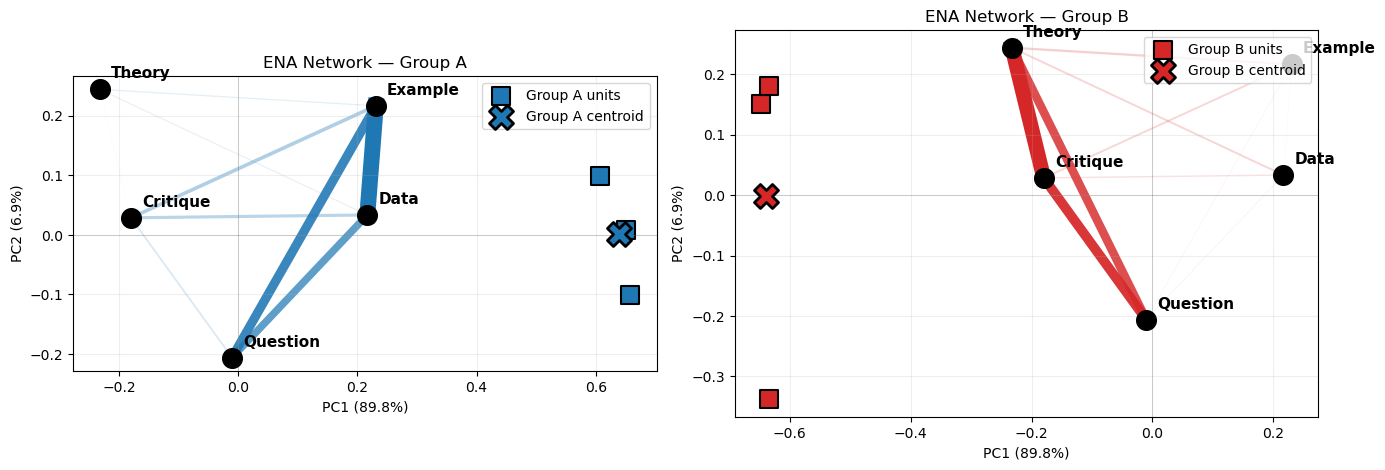


그룹 A에서 가장 강한 코드 쌍 (top 3):
  Data ↔ Example: 0.765
  Question ↔ Example: 0.439
  Data ↔ Question: 0.357

그룹 B에서 가장 강한 코드 쌍 (top 3):
  Theory ↔ Critique: 0.715
  Question ↔ Critique: 0.467
  Theory ↔ Question: 0.409


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 네트워크 노드(코드) 위치 계산
# 각 코드는 그 코드를 포함하는 쌍들의 weight 평균 방향
# Vt[:2]가 변환 매트릭스 → 각 코드 쌍이 2D 공간 어디에 매핑되는지

pair_positions = Vt[:2].T  # (10 pairs, 2)

# 각 코드의 위치 = 그 코드를 포함하는 쌍 위치들의 평균
code_positions = {}
pairs = get_code_pairs(codes)
for code in codes:
    relevant_pair_indices = [i for i, p in enumerate(pairs) if code in p]
    relevant_positions = pair_positions[relevant_pair_indices]
    code_positions[code] = relevant_positions.mean(axis=0)

print("코드 노드 위치:")
for code, pos in code_positions.items():
    print(f"  {code:10s}: x={pos[0]:+.4f}, y={pos[1]:+.4f}")

# 2. 그룹별 평균 네트워크 가중치 (엣지)
# 정규화된 AV의 그룹 평균 = 각 쌍의 평균 강도
group_a_weights = normalized_matrix[avs_df['group']=='A'].mean(axis=0)
group_b_weights = normalized_matrix[avs_df['group']=='B'].mean(axis=0)

# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group_name, weights, color in [
    (axes[0], 'Group A', group_a_weights, 'tab:blue'),
    (axes[1], 'Group B', group_b_weights, 'tab:red')
]:
    # 엣지 그리기
    for i, (c1, c2) in enumerate(pairs):
        p1 = code_positions[c1]
        p2 = code_positions[c2]
        w = weights[i]
        if w > 0.01:  # 너무 작은 건 생략
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                   color=color, alpha=min(w*2, 1.0), 
                   linewidth=w*15, zorder=1)
    
    # 코드 노드
    for code, pos in code_positions.items():
        ax.scatter(pos[0], pos[1], s=200, c='black', zorder=3, marker='o')
        ax.annotate(code, pos, fontsize=11, fontweight='bold',
                   xytext=(8, 8), textcoords='offset points', zorder=4)
    
    # Unit 점들 (해당 그룹만)
    mask = result_df['group'] == group_name.split()[-1]
    ax.scatter(result_df[mask]['x'], result_df[mask]['y'],
              s=150, c=color, marker='s', edgecolor='black', 
              linewidth=1.5, zorder=2, label=f'{group_name} units')
    
    # 그룹 평균 점
    ax.scatter(result_df[mask]['x'].mean(), result_df[mask]['y'].mean(),
              s=300, c=color, marker='X', edgecolor='black',
              linewidth=2, zorder=5, label=f'{group_name} centroid')
    
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    ax.set_title(f'ENA Network — {group_name}')
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('ena_test.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n그룹 A에서 가장 강한 코드 쌍 (top 3):")
top_a = sorted(zip(pairs, group_a_weights), key=lambda x: -x[1])[:3]
for (c1, c2), w in top_a:
    print(f"  {c1} ↔ {c2}: {w:.3f}")

print("\n그룹 B에서 가장 강한 코드 쌍 (top 3):")
top_b = sorted(zip(pairs, group_b_weights), key=lambda x: -x[1])[:3]
for (c1, c2), w in top_b:
    print(f"  {c1} ↔ {c2}: {w:.3f}")

In [10]:
def means_rotation(M_centered, group_labels):
    """
    두 그룹의 평균 차이 방향을 X축으로 회전.
    
    Parameters
    ----------
    M_centered : np.ndarray
        (n_units, n_dims) centering된 정규화 AV matrix
    group_labels : array-like
        각 unit의 그룹 레이블 (길이 n_units, 정확히 2개 그룹)
    
    Returns
    -------
    points : np.ndarray
        (n_units, 2) 회전된 2D 좌표
    rotation_basis : np.ndarray
        (2, n_dims) X, Y축의 단위 벡터 (네트워크 노드 위치 계산용)
    """
    groups = np.unique(group_labels)
    assert len(groups) == 2, f"Means Rotation requires exactly 2 groups, got {len(groups)}"
    
    g1_mean = M_centered[np.array(group_labels) == groups[0]].mean(axis=0)
    g2_mean = M_centered[np.array(group_labels) == groups[1]].mean(axis=0)
    
    # X축: 그룹 차이 방향 (단위 벡터)
    diff = g1_mean - g2_mean
    x_axis = diff / np.linalg.norm(diff)
    
    # 나머지 차원에서 분산 최대 방향을 Y축으로
    # M_centered에서 x_axis 방향 성분 제거 후 SVD
    projection_on_x = M_centered @ x_axis[:, np.newaxis] @ x_axis[np.newaxis, :]
    M_residual = M_centered - projection_on_x
    
    # 잔차의 SVD → 첫 주성분이 Y축
    U_res, S_res, Vt_res = np.linalg.svd(M_residual, full_matrices=False)
    y_axis = Vt_res[0]  # 첫 주성분
    
    # Y축이 X축과 직교한지 검증 (수치 오차 범위)
    orthogonality = np.dot(x_axis, y_axis)
    assert abs(orthogonality) < 1e-10, f"X, Y not orthogonal: {orthogonality}"
    
    # 회전 매트릭스 (2 x n_dims)
    rotation_basis = np.vstack([x_axis, y_axis])
    
    # 모든 unit을 회전된 좌표계로 투영
    points = M_centered @ rotation_basis.T  # (n_units, 2)
    
    return points, rotation_basis


# 적용
group_labels = avs_df['group'].values
points_mr, rotation_basis = means_rotation(M_centered, group_labels)

# 결과 정리
result_mr_df = pd.DataFrame({
    'unit': avs_df['unit'].values,
    'group': group_labels,
    'x': points_mr[:, 0],
    'y': points_mr[:, 1]
})

print("=" * 60)
print("Means Rotation 결과")
print("=" * 60)
print(result_mr_df.round(4).to_string())

print(f"\n그룹별 평균 좌표:")
print(result_mr_df.groupby('group')[['x', 'y']].mean().round(4))

# X축에 그룹 차이가 완전히 흡수됐는지 검증
g1_x = result_mr_df[result_mr_df['group']==groups_unique[0] if 'groups_unique' in dir() else 'A']['x'].mean() if 'A' in group_labels else result_mr_df[result_mr_df['group']==group_labels[0]]['x'].mean()
g_a_x = result_mr_df[result_mr_df['group']=='A']['x'].mean()
g_b_x = result_mr_df[result_mr_df['group']=='B']['x'].mean()
g_a_y = result_mr_df[result_mr_df['group']=='A']['y'].mean()
g_b_y = result_mr_df[result_mr_df['group']=='B']['y'].mean()

print(f"\n검증 — Means Rotation 후 그룹 평균:")
print(f"  Group A centroid: ({g_a_x:+.4f}, {g_a_y:+.4f})")
print(f"  Group B centroid: ({g_b_x:+.4f}, {g_b_y:+.4f})")
print(f"  X축 분리: {abs(g_a_x - g_b_x):.4f}  ← 커야 함 (그룹 차이의 정수)")
print(f"  Y축 분리: {abs(g_a_y - g_b_y):.4f}  ← 0에 가까워야 함 (Y는 그룹 내 변동만)")

# 일반 SVD와 비교
print(f"\n비교 — 일반 SVD 결과 (앞서 한 것):")
print(f"  Group A centroid: ({result_df[result_df['group']=='A']['x'].mean():+.4f}, "
      f"{result_df[result_df['group']=='A']['y'].mean():+.4f})")
print(f"  Group B centroid: ({result_df[result_df['group']=='B']['x'].mean():+.4f}, "
      f"{result_df[result_df['group']=='B']['y'].mean():+.4f})")

Means Rotation 결과
  unit group       x       y
0   A1     A  0.6570  0.1028
1   A2     A  0.6510 -0.0063
2   A3     A  0.6080 -0.0964
3   B1     B -0.6358  0.3358
4   B2     B -0.6470 -0.1531
5   B3     B -0.6332 -0.1827

그룹별 평균 좌표:
            x    y
group             
A      0.6387  0.0
B     -0.6387 -0.0


KeyError: 'A'

In [11]:
g_a_x = result_mr_df[result_mr_df['group']=='A']['x'].mean()
g_b_x = result_mr_df[result_mr_df['group']=='B']['x'].mean()
g_a_y = result_mr_df[result_mr_df['group']=='A']['y'].mean()
g_b_y = result_mr_df[result_mr_df['group']=='B']['y'].mean()

print(f"Means Rotation 후 그룹 평균:")
print(f"  Group A centroid: ({g_a_x:+.4f}, {g_a_y:+.4f})")
print(f"  Group B centroid: ({g_b_x:+.4f}, {g_b_y:+.4f})")
print(f"  X축 분리: {abs(g_a_x - g_b_x):.4f}  ← 그룹 차이의 정수")
print(f"  Y축 분리: {abs(g_a_y - g_b_y):.4f}  ← 0에 가까워야 함 (정의상)")

# 일반 SVD와 비교
print(f"\n일반 SVD 결과 (앞서 한 것):")
svd_a_x = result_df[result_df['group']=='A']['x'].mean()
svd_b_x = result_df[result_df['group']=='B']['x'].mean()
svd_a_y = result_df[result_df['group']=='A']['y'].mean()
svd_b_y = result_df[result_df['group']=='B']['y'].mean()
print(f"  Group A centroid: ({svd_a_x:+.4f}, {svd_a_y:+.4f})")
print(f"  Group B centroid: ({svd_b_x:+.4f}, {svd_b_y:+.4f})")
print(f"  X축 분리: {abs(svd_a_x - svd_b_x):.4f}")
print(f"  Y축 분리: {abs(svd_a_y - svd_b_y):.4f}")

print(f"\n결론:")
print(f"  X축 분리 비교: SVD={abs(svd_a_x - svd_b_x):.4f}, MR={abs(g_a_x - g_b_x):.4f}")
print(f"  Y축 분리 비교: SVD={abs(svd_a_y - svd_b_y):.4f}, MR={abs(g_a_y - g_b_y):.4f}")
print(f"  → Means Rotation은 Y축에 그룹 차이를 남기지 않음 (수학적 보장)")

Means Rotation 후 그룹 평균:
  Group A centroid: (+0.6387, +0.0000)
  Group B centroid: (-0.6387, -0.0000)
  X축 분리: 1.2773  ← 그룹 차이의 정수
  Y축 분리: 0.0000  ← 0에 가까워야 함 (정의상)

일반 SVD 결과 (앞서 한 것):
  Group A centroid: (+0.6387, +0.0017)
  Group B centroid: (-0.6387, -0.0017)
  X축 분리: 1.2773
  Y축 분리: 0.0034

결론:
  X축 분리 비교: SVD=1.2773, MR=1.2773
  Y축 분리 비교: SVD=0.0034, MR=0.0000
  → Means Rotation은 Y축에 그룹 차이를 남기지 않음 (수학적 보장)


In [12]:
from scipy import stats

def ena_group_comparison(points, group_labels, axis='x'):
    """
    ENA 공간에서 두 그룹의 차이를 통계 검정.
    
    Parameters
    ----------
    points : np.ndarray (n_units, 2)
        ENA 2D 좌표
    group_labels : array-like
        각 unit의 그룹 레이블
    axis : str
        'x' 또는 'y' — 어느 축에서 비교할지
    
    Returns
    -------
    dict: 검정 결과
    """
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(group_labels)
    assert len(groups) == 2, "두 그룹 비교만 지원"
    
    group_labels = np.array(group_labels)
    g1_vals = points[group_labels == groups[0], axis_idx]
    g2_vals = points[group_labels == groups[1], axis_idx]
    
    # 1. Mann-Whitney U (비모수, n 작아도 가능)
    u_stat, u_pval = stats.mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    
    # 2. Welch's t-test (등분산 가정 안 함)
    t_stat, t_pval = stats.ttest_ind(g1_vals, g2_vals, equal_var=False)
    
    # 3. Cohen's d (효과크기)
    n1, n2 = len(g1_vals), len(g2_vals)
    pooled_std = np.sqrt(((n1-1)*g1_vals.var(ddof=1) + (n2-1)*g2_vals.var(ddof=1)) / (n1+n2-2))
    cohens_d = (g1_vals.mean() - g2_vals.mean()) / pooled_std if pooled_std > 0 else np.inf
    
    return {
        'axis': axis,
        'group1': groups[0],
        'group2': groups[1],
        'g1_mean': g1_vals.mean(),
        'g1_std': g1_vals.std(ddof=1),
        'g2_mean': g2_vals.mean(),
        'g2_std': g2_vals.std(ddof=1),
        'mean_diff': g1_vals.mean() - g2_vals.mean(),
        'mannwhitney_U': u_stat,
        'mannwhitney_p': u_pval,
        'welch_t': t_stat,
        'welch_p': t_pval,
        'cohens_d': cohens_d,
    }


def print_comparison_report(result):
    """결과를 학술 논문 스타일로 출력"""
    print(f"=" * 60)
    print(f"ENA Group Comparison — {result['axis'].upper()}-axis")
    print(f"=" * 60)
    print(f"\nDescriptive statistics:")
    print(f"  {result['group1']}: M = {result['g1_mean']:+.4f}, SD = {result['g1_std']:.4f}")
    print(f"  {result['group2']}: M = {result['g2_mean']:+.4f}, SD = {result['g2_std']:.4f}")
    print(f"  Mean difference: {result['mean_diff']:+.4f}")
    
    print(f"\nMann-Whitney U test (non-parametric):")
    print(f"  U = {result['mannwhitney_U']:.2f}, p = {result['mannwhitney_p']:.4f}")
    
    print(f"\nWelch's t-test:")
    print(f"  t = {result['welch_t']:+.4f}, p = {result['welch_p']:.4f}")
    
    print(f"\nEffect size:")
    d = result['cohens_d']
    if abs(d) < 0.2:
        effect = "negligible"
    elif abs(d) < 0.5:
        effect = "small"
    elif abs(d) < 0.8:
        effect = "medium"
    else:
        effect = "large"
    print(f"  Cohen's d = {d:+.4f}  ({effect})")
    
    print(f"\n해석:")
    sig = "유의함" if result['mannwhitney_p'] < 0.05 else "유의하지 않음"
    print(f"  {result['axis'].upper()}축에서 두 그룹 차이는 통계적으로 {sig} (α = 0.05)")


# X축에서 그룹 비교 (Means Rotation 결과)
print("【Means Rotation 결과로 검정】\n")
result_x = ena_group_comparison(points_mr, group_labels, axis='x')
print_comparison_report(result_x)

print("\n")

# Y축도 확인 (Y는 그룹 차이 없어야 함)
result_y = ena_group_comparison(points_mr, group_labels, axis='y')
print_comparison_report(result_y)

【Means Rotation 결과로 검정】

ENA Group Comparison — X-axis

Descriptive statistics:
  A: M = +0.6387, SD = 0.0267
  B: M = -0.6387, SD = 0.0074
  Mean difference: +1.2773

Mann-Whitney U test (non-parametric):
  U = 9.00, p = 0.1000

Welch's t-test:
  t = +79.8425, p = 0.0001

Effect size:
  Cohen's d = +65.1911  (large)

해석:
  X축에서 두 그룹 차이는 통계적으로 유의하지 않음 (α = 0.05)


ENA Group Comparison — Y-axis

Descriptive statistics:
  A: M = +0.0000, SD = 0.0997
  B: M = -0.0000, SD = 0.2912
  Mean difference: +0.0000

Mann-Whitney U test (non-parametric):
  U = 6.00, p = 0.7000

Welch's t-test:
  t = +0.0000, p = 1.0000

Effect size:
  Cohen's d = +0.0000  (negligible)

해석:
  Y축에서 두 그룹 차이는 통계적으로 유의하지 않음 (α = 0.05)


In [13]:
import warnings

def ena_group_comparison_v2(points, group_labels, axis='x', n_permutations=10000, 
                             random_state=42):
    """
    개선된 ENA 그룹 비교: 작은 표본 경고 + Permutation test 추가.
    """
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(group_labels)
    assert len(groups) == 2, "두 그룹 비교만 지원"
    
    group_labels = np.array(group_labels)
    g1_vals = points[group_labels == groups[0], axis_idx]
    g2_vals = points[group_labels == groups[1], axis_idx]
    n1, n2 = len(g1_vals), len(g2_vals)
    
    # 작은 표본 경고
    if min(n1, n2) < 4:
        warnings.warn(
            f"Small sample warning: n1={n1}, n2={n2}. "
            f"Mann-Whitney U cannot achieve p<0.05 with n<4 per group. "
            f"Consider permutation test or larger samples.",
            UserWarning
        )
    
    # 기본 검정들
    u_stat, u_pval = stats.mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    t_stat, t_pval = stats.ttest_ind(g1_vals, g2_vals, equal_var=False)
    
    # Permutation test — 작은 표본에서 가장 robust
    observed_diff = g1_vals.mean() - g2_vals.mean()
    combined = np.concatenate([g1_vals, g2_vals])
    rng = np.random.default_rng(random_state)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        perm_diffs[i] = shuffled[:n1].mean() - shuffled[n1:].mean()
    perm_pval = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
    
    # Cohen's d
    pooled_std = np.sqrt(((n1-1)*g1_vals.var(ddof=1) + (n2-1)*g2_vals.var(ddof=1)) / (n1+n2-2))
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else np.inf
    
    # 이론적 최소 가능 Mann-Whitney p값 (작은 표본 진단용)
    from math import comb
    min_possible_p = 2 / comb(n1 + n2, n1)  # 양측, 극단 케이스
    
    return {
        'axis': axis,
        'n1': n1, 'n2': n2,
        'g1_mean': g1_vals.mean(), 'g1_std': g1_vals.std(ddof=1),
        'g2_mean': g2_vals.mean(), 'g2_std': g2_vals.std(ddof=1),
        'observed_diff': observed_diff,
        'mannwhitney_U': u_stat, 'mannwhitney_p': u_pval,
        'mannwhitney_min_possible_p': min_possible_p,
        'welch_t': t_stat, 'welch_p': t_pval,
        'permutation_p': perm_pval,
        'permutation_n': n_permutations,
        'cohens_d': cohens_d,
    }


def print_v2_report(result):
    print(f"=" * 60)
    print(f"ENA Group Comparison v2 — {result['axis'].upper()}-axis")
    print(f"=" * 60)
    print(f"\nSample: n1={result['n1']}, n2={result['n2']}")
    print(f"\nDescriptive:")
    print(f"  Group 1: M = {result['g1_mean']:+.4f}, SD = {result['g1_std']:.4f}")
    print(f"  Group 2: M = {result['g2_mean']:+.4f}, SD = {result['g2_std']:.4f}")
    print(f"  Observed difference: {result['observed_diff']:+.4f}")
    print(f"\nStatistical tests:")
    print(f"  Welch's t:        t = {result['welch_t']:+.2f},  p = {result['welch_p']:.4f}")
    print(f"  Mann-Whitney U:   U = {result['mannwhitney_U']:.1f},   p = {result['mannwhitney_p']:.4f}")
    print(f"    (theoretical min possible p for this sample size: {result['mannwhitney_min_possible_p']:.4f})")
    print(f"  Permutation test: p = {result['permutation_p']:.4f}  (n_perm = {result['permutation_n']})")
    print(f"\nEffect size:")
    d = result['cohens_d']
    effect = "negligible" if abs(d) < 0.2 else ("small" if abs(d) < 0.5 else 
              ("medium" if abs(d) < 0.8 else "large"))
    print(f"  Cohen's d = {d:+.4f}  ({effect})")


# 적용
result_x_v2 = ena_group_comparison_v2(points_mr, group_labels, axis='x')
print_v2_report(result_x_v2)

print("\n")

result_y_v2 = ena_group_comparison_v2(points_mr, group_labels, axis='y')
print_v2_report(result_y_v2)

ENA Group Comparison v2 — X-axis

Sample: n1=3, n2=3

Descriptive:
  Group 1: M = +0.6387, SD = 0.0267
  Group 2: M = -0.6387, SD = 0.0074
  Observed difference: +1.2773

Statistical tests:
  Welch's t:        t = +79.84,  p = 0.0001
  Mann-Whitney U:   U = 9.0,   p = 0.1000
    (theoretical min possible p for this sample size: 0.1000)
  Permutation test: p = 0.1008  (n_perm = 10000)

Effect size:
  Cohen's d = +65.1911  (large)


ENA Group Comparison v2 — Y-axis

Sample: n1=3, n2=3

Descriptive:
  Group 1: M = +0.0000, SD = 0.0997
  Group 2: M = -0.0000, SD = 0.2912
  Observed difference: +0.0000

Statistical tests:
  Welch's t:        t = +0.00,  p = 1.0000
  Mann-Whitney U:   U = 6.0,   p = 0.7000
    (theoretical min possible p for this sample size: 0.1000)
  Permutation test: p = 0.9778  (n_perm = 10000)

Effect size:
  Cohen's d = +0.0000  (negligible)


/tmp/ipykernel_214366/2028930758.py:19: UserWarning: Small sample warning: n1=3, n2=3. Mann-Whitney U cannot achieve p<0.05 with n<4 per group. Consider permutation test or larger samples.
  warnings.warn(


In [14]:
np.random.seed(42)

def generate_run(unit_id, group, base_probs, jitter, n_turns=20):
    """
    한 번의 실행(run)을 생성.
    base_probs: 그룹별 기준 코드 확률
    jitter: 실행 간 확률 변동 폭 (작으면 수렴, 크면 발산)
    """
    # 이 run만의 실제 확률 = base + 노이즈
    actual_probs = {}
    for code, p in base_probs.items():
        noise = np.random.uniform(-jitter, jitter)
        actual_probs[code] = max(0.01, min(0.99, p + noise))
    
    rows = []
    for turn in range(n_turns):
        row = {
            'unit': unit_id,
            'group': group,
            'conversation': f"{unit_id}_session",
            'turn': turn,
        }
        for code in codes:
            row[code] = int(np.random.random() < actual_probs[code])
        rows.append(row)
    return rows


# 3그룹 시나리오
# A_tight: "Data·Example 패턴, 안정적 모델" — jitter 작음
# A_loose: "같은 Data·Example 패턴이지만 불안정한 모델" — jitter 큼
# B_tight: "Theory·Critique 패턴, 안정적 모델"

probs_A = {'Data': 0.5, 'Theory': 0.05, 'Question': 0.2, 
           'Example': 0.4, 'Critique': 0.1}
probs_B = {'Data': 0.05, 'Theory': 0.5, 'Question': 0.2, 
           'Example': 0.1, 'Critique': 0.4}

N_PER_GROUP = 30
all_rows = []

# A_tight: jitter 0.03
for i in range(1, N_PER_GROUP + 1):
    all_rows.extend(generate_run(f"At{i:02d}", 'A_tight', probs_A, jitter=0.03))

# A_loose: jitter 0.20 (같은 base이지만 훨씬 큰 변동)
for i in range(1, N_PER_GROUP + 1):
    all_rows.extend(generate_run(f"Al{i:02d}", 'A_loose', probs_A, jitter=0.20))

# B_tight: jitter 0.03
for i in range(1, N_PER_GROUP + 1):
    all_rows.extend(generate_run(f"Bt{i:02d}", 'B_tight', probs_B, jitter=0.03))

df_large = pd.DataFrame(all_rows)

print(f"Shape: {df_large.shape}")
print(f"Total units: {df_large['unit'].nunique()}")
print(f"\nGroup distribution:")
print(df_large.groupby('group')['unit'].nunique())

print(f"\nCode counts (그룹 평균, per unit per turn):")
per_unit_avg = df_large.groupby(['group', 'unit'])[codes].sum() / 20  # 20 turns
print(per_unit_avg.groupby('group').mean().round(3))

print(f"\nCode count 표준편차 (그룹별, unit 간):")
print(per_unit_avg.groupby('group').std().round(3))

Shape: (1800, 9)
Total units: 90

Group distribution:
group
A_loose    30
A_tight    30
B_tight    30
Name: unit, dtype: int64

Code counts (그룹 평균, per unit per turn):
          Data  Theory  Question  Example  Critique
group                                              
A_loose  0.512   0.082     0.230    0.420     0.133
A_tight  0.500   0.067     0.207    0.398     0.110
B_tight  0.068   0.525     0.200    0.083     0.407

Code count 표준편차 (그룹별, unit 간):
          Data  Theory  Question  Example  Critique
group                                              
A_loose  0.146   0.113     0.144    0.157     0.128
A_tight  0.100   0.055     0.096    0.093     0.070
B_tight  0.059   0.099     0.097    0.063     0.099


In [15]:
# 1. 모든 unit의 AV 계산
avs_large = compute_all_avs(df_large, codes, stanza_window=4)

# 2. 정규화
pair_cols = [c for c in avs_large.columns if c not in ['unit', 'group']]
av_matrix_large = avs_large[pair_cols].values
M_norm = np.array([sphere_normalize(row) for row in av_matrix_large])

# 3. Centering
M_centered_large = M_norm - M_norm.mean(axis=0)

# 4. SVD
U_l, S_l, Vt_l = np.linalg.svd(M_centered_large, full_matrices=False)
explained_var = S_l**2 / (S_l**2).sum()

# 5. 2D 투영
points_large = M_centered_large @ Vt_l[:2].T

# 결과 정리
result_large = pd.DataFrame({
    'unit': avs_large['unit'].values,
    'group': avs_large['group'].values,
    'x': points_large[:, 0],
    'y': points_large[:, 1]
})

print(f"Shape: {result_large.shape}")
print(f"\n각 주성분 설명 분산:")
for i in range(5):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}%")
print(f"  PC1+PC2: {explained_var[:2].sum()*100:.2f}%")

print(f"\n그룹별 centroid + 산포:")
summary = result_large.groupby('group').agg(
    n=('unit', 'count'),
    x_mean=('x', 'mean'),
    x_std=('x', 'std'),
    y_mean=('y', 'mean'),
    y_std=('y', 'std'),
).round(4)
print(summary)

Shape: (90, 4)

각 주성분 설명 분산:
  PC1: 65.94%
  PC2: 11.11%
  PC3: 7.85%
  PC4: 5.46%
  PC5: 3.80%
  PC1+PC2: 77.04%

그룹별 centroid + 산포:
          n  x_mean   x_std  y_mean   y_std
group                                      
A_loose  30 -0.3542  0.1396 -0.0093  0.3123
A_tight  30 -0.4086  0.0884  0.0000  0.2290
B_tight  30  0.7628  0.0817  0.0093  0.0891


In [16]:
from scipy.spatial import ConvexHull
from scipy.stats import chi2

def reproducibility_metrics(points, group_labels=None):
    """
    ENA 공간에서 unit들의 reproducibility(수렴도)를 정량화.
    
    각 그룹(또는 전체)에 대해 4가지 지표 계산.
    낮을수록 수렴, 높을수록 발산.
    
    Parameters
    ----------
    points : np.ndarray (n_units, 2)
        ENA 2D 좌표
    group_labels : array-like or None
        그룹별로 계산. None이면 전체 데이터에 적용
    
    Returns
    -------
    DataFrame: 그룹별 reproducibility 지표
    """
    
    def _compute_one_group(pts):
        """한 그룹의 reproducibility metrics 계산"""
        n = len(pts)
        centroid = pts.mean(axis=0)
        
        # 1. Centroid dispersion: 각 점에서 centroid까지의 평균 거리
        distances_to_centroid = np.linalg.norm(pts - centroid, axis=1)
        centroid_dispersion = distances_to_centroid.mean()
        centroid_dispersion_std = distances_to_centroid.std()
        
        # 2. Pairwise mean distance: 모든 점 쌍의 평균 거리
        if n >= 2:
            from scipy.spatial.distance import pdist
            pairwise = pdist(pts)
            pairwise_mean = pairwise.mean()
            pairwise_max = pairwise.max()
        else:
            pairwise_mean = np.nan
            pairwise_max = np.nan
        
        # 3. 95% Confidence ellipse area (다변량 정규성 가정 하)
        # 공분산 매트릭스의 고유값으로 ellipse 축 길이
        if n >= 3:
            cov = np.cov(pts.T)
            eigenvals = np.linalg.eigvalsh(cov)
            # chi-square 임계값 (2 자유도, 0.95)
            chi2_val = chi2.ppf(0.95, df=2)
            # 면적 = π × a × b, where a,b = sqrt(chi2 × eigenvals)
            ellipse_area = np.pi * chi2_val * np.sqrt(np.prod(eigenvals))
        else:
            ellipse_area = np.nan
        
        # 4. Convex hull area (실제 점들이 차지한 영역)
        if n >= 3:
            try:
                hull = ConvexHull(pts)
                hull_area = hull.volume  # 2D에서 volume = area
            except Exception:
                hull_area = np.nan  # 점이 일직선인 경우
        else:
            hull_area = np.nan
        
        return {
            'n': n,
            'centroid_x': centroid[0],
            'centroid_y': centroid[1],
            'centroid_dispersion_mean': centroid_dispersion,
            'centroid_dispersion_std': centroid_dispersion_std,
            'pairwise_distance_mean': pairwise_mean,
            'pairwise_distance_max': pairwise_max,
            'ellipse_95_area': ellipse_area,
            'convex_hull_area': hull_area,
        }
    
    if group_labels is None:
        return pd.DataFrame([_compute_one_group(points)], index=['all'])
    
    group_labels = np.array(group_labels)
    results = {}
    for g in np.unique(group_labels):
        pts_g = points[group_labels == g]
        results[g] = _compute_one_group(pts_g)
    
    return pd.DataFrame(results).T


# 적용
repro = reproducibility_metrics(points_large, result_large['group'].values)
print("Reproducibility Metrics by Group:")
print(repro.round(4).to_string())

# 핵심 비교
print(f"\n핵심 비교 — A_tight vs A_loose (같은 base, 다른 stochasticity):")
print(f"  Centroid dispersion: A_tight={repro.loc['A_tight','centroid_dispersion_mean']:.4f}, "
      f"A_loose={repro.loc['A_loose','centroid_dispersion_mean']:.4f}, "
      f"ratio={repro.loc['A_loose','centroid_dispersion_mean']/repro.loc['A_tight','centroid_dispersion_mean']:.2f}x")
print(f"  Pairwise distance:   A_tight={repro.loc['A_tight','pairwise_distance_mean']:.4f}, "
      f"A_loose={repro.loc['A_loose','pairwise_distance_mean']:.4f}, "
      f"ratio={repro.loc['A_loose','pairwise_distance_mean']/repro.loc['A_tight','pairwise_distance_mean']:.2f}x")
print(f"  95% Ellipse area:    A_tight={repro.loc['A_tight','ellipse_95_area']:.4f}, "
      f"A_loose={repro.loc['A_loose','ellipse_95_area']:.4f}, "
      f"ratio={repro.loc['A_loose','ellipse_95_area']/repro.loc['A_tight','ellipse_95_area']:.2f}x")
print(f"  Convex hull area:    A_tight={repro.loc['A_tight','convex_hull_area']:.4f}, "
      f"A_loose={repro.loc['A_loose','convex_hull_area']:.4f}, "
      f"ratio={repro.loc['A_loose','convex_hull_area']/repro.loc['A_tight','convex_hull_area']:.2f}x")

Reproducibility Metrics by Group:
            n  centroid_x  centroid_y  centroid_dispersion_mean  centroid_dispersion_std  pairwise_distance_mean  pairwise_distance_max  ellipse_95_area  convex_hull_area
A_loose  30.0     -0.3542     -0.0093                    0.2927                   0.1658                  0.4176                 1.2343           0.8095            0.4474
A_tight  30.0     -0.4086      0.0000                    0.2148                   0.1101                  0.3017                 0.8106           0.3599            0.1763
B_tight  30.0      0.7628      0.0093                    0.1032                   0.0589                  0.1455                 0.4028           0.1235            0.0614

핵심 비교 — A_tight vs A_loose (같은 base, 다른 stochasticity):
  Centroid dispersion: A_tight=0.2148, A_loose=0.2927, ratio=1.36x
  Pairwise distance:   A_tight=0.3017, A_loose=0.4176, ratio=1.38x
  95% Ellipse area:    A_tight=0.3599, A_loose=0.8095, ratio=2.25x
  Convex hull area:    A

/tmp/ipykernel_214366/2311498199.py:65: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_214366/2311498199.py:65: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_214366/2311498199.py:65: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_214366/2311498199.py:65: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_214366/2311498199.py:66: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.savefig('reproducibility_viz.png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_214366/2311498199.py:66: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.savefig('reproducibility_viz.png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_214366/

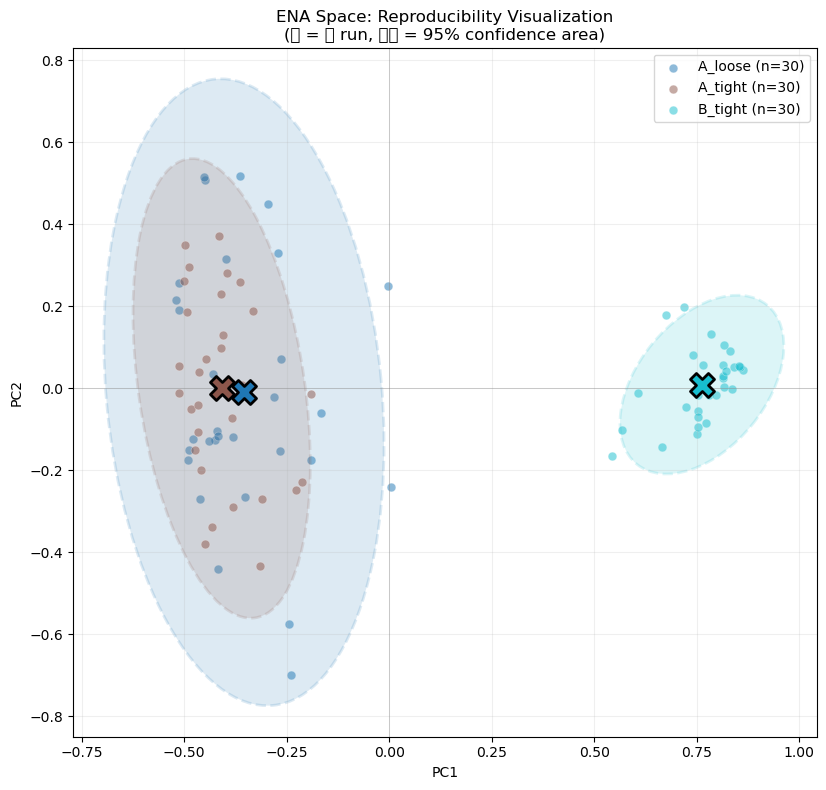


Reproducibility 차이의 통계 검정

Levene's test (모든 그룹의 산포 동일성):
  W = 12.5145, p = 0.000017

A_tight vs A_loose (Levene's test):
  W = 3.5024, p = 0.066328
  → 차이가 유의하지 않음

A_tight vs A_loose centroid distances (Mann-Whitney U, one-sided):
  U = 339.00, p = 0.051163
  H1: A_tight의 centroid 거리 < A_loose의 centroid 거리


In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2 as chi2_dist

def plot_reproducibility(points, group_labels, ax=None, 
                          colors=None, show_ellipse=True, show_hull=False):
    """
    각 그룹을 다른 색으로, 95% confidence ellipse와 함께 시각화.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    
    group_labels = np.array(group_labels)
    groups = np.unique(group_labels)
    
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    
    for g, color in zip(groups, colors):
        mask = group_labels == g
        pts = points[mask]
        
        # 개별 점들
        ax.scatter(pts[:, 0], pts[:, 1], s=40, alpha=0.5, 
                   color=color, label=f'{g} (n={mask.sum()})',
                   edgecolor='white', linewidth=0.5)
        
        # Centroid
        centroid = pts.mean(axis=0)
        ax.scatter(centroid[0], centroid[1], s=300, marker='X', 
                   color=color, edgecolor='black', linewidth=2, zorder=5)
        
        # 95% confidence ellipse
        if show_ellipse and len(pts) >= 3:
            cov = np.cov(pts.T)
            eigenvals, eigenvecs = np.linalg.eigh(cov)
            # 큰 고유값이 첫 번째가 되도록
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            chi2_val = chi2_dist.ppf(0.95, df=2)
            width = 2 * np.sqrt(chi2_val * eigenvals[0])
            height = 2 * np.sqrt(chi2_val * eigenvals[1])
            
            ellipse = Ellipse(centroid, width, height, angle=angle,
                              facecolor=color, alpha=0.15, edgecolor=color,
                              linewidth=2, linestyle='--')
            ax.add_patch(ellipse)
    
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title('ENA Space: Reproducibility Visualization\n(점 = 각 run, 타원 = 95% confidence area)')
    ax.legend(loc='best')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    return ax

fig, ax = plt.subplots(figsize=(10, 8))
plot_reproducibility(points_large, result_large['group'].values, ax=ax)
plt.tight_layout()
plt.savefig('reproducibility_viz.png', dpi=100, bbox_inches='tight')
plt.show()

# Reproducibility 차이의 통계 검정
# 각 unit의 centroid distance를 그룹별로 비교 (Levene's test for spread)
from scipy.stats import levene, f_oneway

print("\n" + "="*60)
print("Reproducibility 차이의 통계 검정")
print("="*60)

# 각 점의 centroid 거리
distances_by_group = {}
for g in np.unique(result_large['group']):
    mask = result_large['group'].values == g
    pts = points_large[mask]
    centroid = pts.mean(axis=0)
    distances_by_group[g] = np.linalg.norm(pts - centroid, axis=1)

# Levene's test: 분산의 동일성 검정 (산포 차이)
groups_keys = list(distances_by_group.keys())
levene_stat, levene_p = levene(*[distances_by_group[g] for g in groups_keys])
print(f"\nLevene's test (모든 그룹의 산포 동일성):")
print(f"  W = {levene_stat:.4f}, p = {levene_p:.6f}")

# A_tight vs A_loose 직접 비교
levene_pair, levene_pair_p = levene(distances_by_group['A_tight'], 
                                      distances_by_group['A_loose'])
print(f"\nA_tight vs A_loose (Levene's test):")
print(f"  W = {levene_pair:.4f}, p = {levene_pair_p:.6f}")
if levene_pair_p < 0.05:
    print(f"  → A_loose가 A_tight보다 통계적으로 유의하게 발산함 (p < 0.05)")
else:
    print(f"  → 차이가 유의하지 않음")

# 추가: 거리 평균 자체의 차이도 검정
from scipy.stats import mannwhitneyu
u, p_u = mannwhitneyu(distances_by_group['A_tight'], 
                       distances_by_group['A_loose'], 
                       alternative='less')
print(f"\nA_tight vs A_loose centroid distances (Mann-Whitney U, one-sided):")
print(f"  U = {u:.2f}, p = {p_u:.6f}")
print(f"  H1: A_tight의 centroid 거리 < A_loose의 centroid 거리")

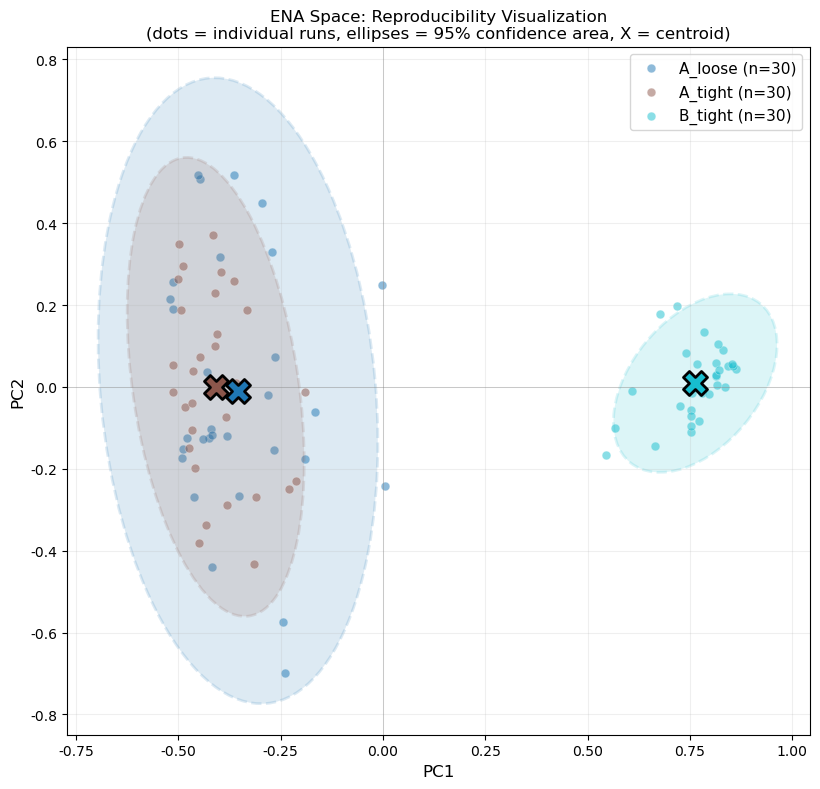

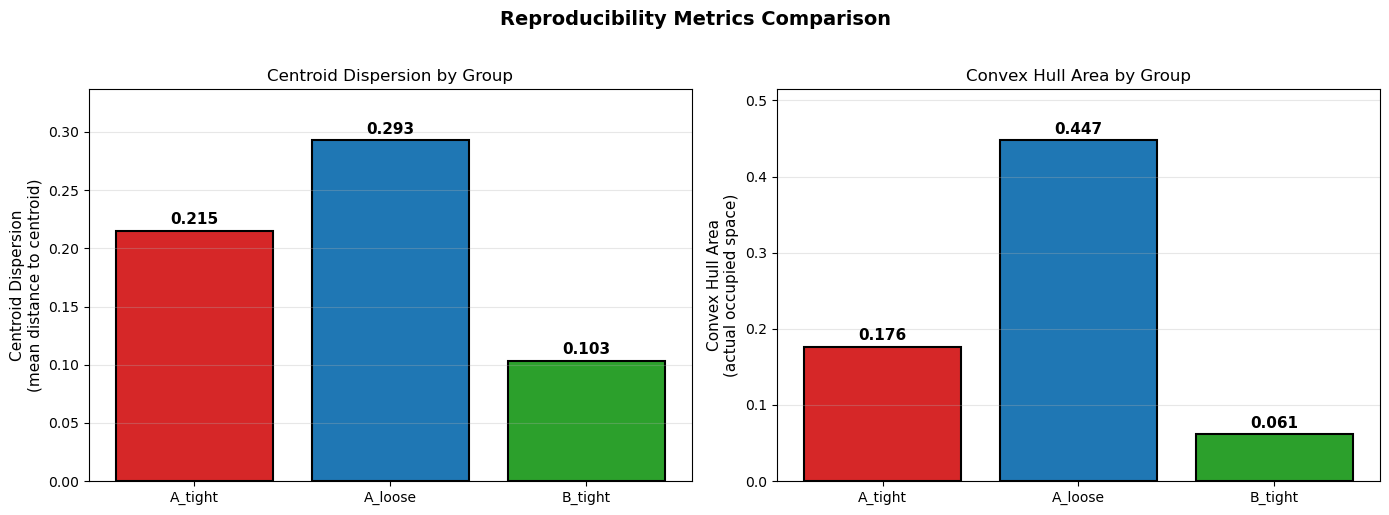

Figures saved:
  - reproducibility_viz_en.png
  - reproducibility_metrics_en.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 폰트 설정: 영어 기본 + 한글 깨짐 방지 (한글은 안 쓸 거지만 경고 막기 위해)
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

def plot_reproducibility_en(points, group_labels, ax=None, 
                              colors=None, show_ellipse=True,
                              title='ENA Space: Reproducibility Visualization'):
    """
    English-labeled version for publication.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    group_labels = np.array(group_labels)
    groups = np.unique(group_labels)
    
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    
    for g, color in zip(groups, colors):
        mask = group_labels == g
        pts = points[mask]
        
        ax.scatter(pts[:, 0], pts[:, 1], s=40, alpha=0.5, 
                   color=color, label=f'{g} (n={mask.sum()})',
                   edgecolor='white', linewidth=0.5)
        
        centroid = pts.mean(axis=0)
        ax.scatter(centroid[0], centroid[1], s=300, marker='X', 
                   color=color, edgecolor='black', linewidth=2, zorder=5)
        
        if show_ellipse and len(pts) >= 3:
            cov = np.cov(pts.T)
            eigenvals, eigenvecs = np.linalg.eigh(cov)
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            chi2_val = chi2_dist.ppf(0.95, df=2)
            width = 2 * np.sqrt(chi2_val * eigenvals[0])
            height = 2 * np.sqrt(chi2_val * eigenvals[1])
            
            ellipse = Ellipse(centroid, width, height, angle=angle,
                              facecolor=color, alpha=0.15, edgecolor=color,
                              linewidth=2, linestyle='--')
            ax.add_patch(ellipse)
    
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title(f'{title}\n(dots = individual runs, ellipses = 95% confidence area, X = centroid)',
                 fontsize=12)
    ax.legend(loc='best', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    return ax


# 메인 그림
fig, ax = plt.subplots(figsize=(11, 8))
plot_reproducibility_en(points_large, result_large['group'].values, ax=ax)
plt.tight_layout()
plt.savefig('reproducibility_viz_en.png', dpi=150, bbox_inches='tight')
plt.show()


# 보조 그림: reproducibility metric 비교 bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = [
    ('centroid_dispersion_mean', 'Centroid Dispersion\n(mean distance to centroid)'),
    ('convex_hull_area', 'Convex Hull Area\n(actual occupied space)')
]

group_order = ['A_tight', 'A_loose', 'B_tight']
group_colors = ['#d62728', '#1f77b4', '#2ca02c']

for ax, (metric, label) in zip(axes, metrics_to_plot):
    values = [repro.loc[g, metric] for g in group_order]
    bars = ax.bar(group_order, values, color=group_colors, edgecolor='black', linewidth=1.5)
    
    # 값 표시
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label.split(chr(10))[0]} by Group', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(values) * 1.15)

plt.suptitle('Reproducibility Metrics Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reproducibility_metrics_en.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figures saved:")
print("  - reproducibility_viz_en.png")
print("  - reproducibility_metrics_en.png")

In [19]:
# rpy2 설치 여부 확인
try:
    import rpy2
    print(f"rpy2: {rpy2.__version__}")
    
    import rpy2.robjects as ro
    from rpy2.robjects.packages import importr
    
    # R 버전 확인
    print(f"R version: {ro.r('R.version.string')[0]}")
    
    # rENA 설치 여부
    try:
        utils = importr('utils')
        installed = list(ro.r('installed.packages()[,1]'))
        if 'rENA' in installed:
            print("rENA: installed")
            rena = importr('rENA')
            print(f"  rENA version: {ro.r('packageVersion(\"rENA\")')[0]}")
        else:
            print("rENA: NOT installed")
            print("  → need to install: install.packages('rENA')")
    except Exception as e:
        print(f"rENA check failed: {e}")
        
except ImportError:
    print("rpy2: NOT installed")
    print("  → conda install -c conda-forge rpy2")

rpy2: NOT installed
  → conda install -c conda-forge rpy2


In [20]:
import pickle
from pathlib import Path

# 작업 디렉토리 확인
Path('./data').mkdir(exist_ok=True)

# 1. 토이 데이터 저장
df_large.to_csv('./data/toy_data_n90.csv', index=False)
print(f"Saved: ./data/toy_data_n90.csv  (shape: {df_large.shape})")

# 2. 핵심 결과 저장 (rENA 비교에 사용할 reference)
reference_data = {
    'codes': codes,
    'stanza_window': 4,
    'av_matrix': av_matrix_large,       # 정규화 전 raw AV
    'normalized_matrix': M_norm,         # 정규화된 AV
    'centered_matrix': M_centered_large, # centering된 매트릭스
    'points_2d': points_large,           # 최종 ENA 좌표
    'singular_values': S_l,
    'Vt': Vt_l,
    'group_labels': result_large['group'].values,
    'unit_ids': result_large['unit'].values,
}

with open('./data/pyena_reference_output.pkl', 'wb') as f:
    pickle.dump(reference_data, f)
print(f"Saved: ./data/pyena_reference_output.pkl")

# 3. 함수 정의도 별도로 저장해두면 새 노트북에서 import 가능
print("\n저장된 파일들:")
import os
for f in sorted(os.listdir('./data')):
    size = os.path.getsize(f'./data/{f}')
    print(f"  {f}: {size:,} bytes")

Saved: ./data/toy_data_n90.csv  (shape: (1800, 9))
Saved: ./data/pyena_reference_output.pkl

저장된 파일들:
  pyena_reference_output.pkl: 25,368 bytes
  toy_data_n90.csv: 69,367 bytes


In [21]:
import subprocess
import os
from pathlib import Path

# 작업용 임시 디렉토리
src_dir = Path('./rena_source')
src_dir.mkdir(exist_ok=True)

# 1. CRAN에서 rENA 0.3.1 source tarball 다운로드
print("rENA 0.3.1 source 다운로드 중...")
url = "https://cran.r-project.org/src/contrib/rENA_0.3.1.tar.gz"
result = subprocess.run(
    ['wget', '-q', '-O', str(src_dir / 'rENA.tar.gz'), url],
    capture_output=True, text=True
)
print(f"  완료" if result.returncode == 0 else f"  실패: {result.stderr}")

# 2. 압축 해제
print("\n압축 해제 중...")
result = subprocess.run(
    ['tar', '-xzf', str(src_dir / 'rENA.tar.gz'), '-C', str(src_dir)],
    capture_output=True, text=True
)
print(f"  완료" if result.returncode == 0 else f"  실패: {result.stderr}")

# 3. src 폴더 확인
src_files_dir = src_dir / 'rENA' / 'src'
print(f"\nsrc 폴더 위치: {src_files_dir}")
print(f"내용:")
if src_files_dir.exists():
    for f in sorted(src_files_dir.iterdir()):
        size = f.stat().st_size
        print(f"  {f.name}: {size:,} bytes")

# 4. ref_window_df가 들어있는 파일 찾기
print(f"\n'ref_window_df' 검색:")
for f in src_files_dir.glob('*.cpp'):
    with open(f, 'r') as file:
        content = file.read()
    if 'ref_window_df' in content:
        print(f"  ✓ 발견: {f.name}")
        # 함수 위치 찾기
        idx = content.find('ref_window_df')
        # 함수 정의를 찾기 위해 약간 더 넓게
        start = max(0, content.rfind('\n', 0, idx) - 200)
        end = min(len(content), idx + 3000)
        snippet = content[start:end]
        print(f"\n=== {f.name}에서 ref_window_df 정의 (snippet) ===")
        print(snippet)

rENA 0.3.1 source 다운로드 중...
  완료

압축 해제 중...
  완료

src 폴더 위치: rena_source/rENA/src
내용:
  Makevars: 1,136 bytes
  Makevars.win: 491 bytes
  RcppExports.cpp: 25,685 bytes
  ena.cpp: 21,993 bytes

'ref_window_df' 검색:
  ✓ 발견: RcppExports.cpp

=== RcppExports.cpp에서 ref_window_df 정의 (snippet) ===
isError_gen) {
        SEXP rcpp_msgSEXP_gen = Rf_asChar(rcpp_result_gen);
        UNPROTECT(1);
        (Rf_error)("%s", CHAR(rcpp_msgSEXP_gen));
    }
    UNPROTECT(1);
    return rcpp_result_gen;
}
// ref_window_df
Rcpp::DataFrame ref_window_df(Rcpp::DataFrame df, float windowSize, float windowForward, bool binary);
static SEXP _rENA_ref_window_df_try(SEXP dfSEXP, SEXP windowSizeSEXP, SEXP windowForwardSEXP, SEXP binarySEXP) {
BEGIN_RCPP
    Rcpp::RObject rcpp_result_gen;
    Rcpp::traits::input_parameter< Rcpp::DataFrame >::type df(dfSEXP);
    Rcpp::traits::input_parameter< float >::type windowSize(windowSizeSEXP);
    Rcpp::traits::input_parameter< float >::type windowForward(windowForwardSEXP

In [22]:
# ena.cpp에서 ref_window_df 함수 전체 보기
import subprocess
result = subprocess.run(
    ['grep', '-n', 'ref_window_df\|vector_to_ut', './rena_source/rENA/src/ena.cpp'],
    capture_output=True, text=True
)
print("관련 라인 번호:")
print(result.stdout)

# ena.cpp 파일 전체 길이 확인
with open('./rena_source/rENA/src/ena.cpp', 'r') as f:
    lines = f.readlines()
print(f"\nena.cpp 총 {len(lines)} 줄")

관련 라인 번호:
142:arma::rowvec vector_to_ut(arma::mat v) {
158:std::vector<std::string> svector_to_ut(std::vector<std::string> v) {
186:    df_CoOccurred.row(row) = vector_to_ut(df_AsMatrix2.row(row));
196:// @title ref_window_df
197:// @name ref_window_df
205:Rcpp::DataFrame ref_window_df(
269:    arma::rowvec toUT = vector_to_ut(currRowsSummed);
285:        arma::rowvec toUT_refs = vector_to_ut(currRow_refsSummed);
296:        arma::rowvec toUT_refs = vector_to_ut(currRow_refsSummed);
692:#   (codedTriNames) := ref_window_df(
705:#   (codedTriNames) := ref_window_df(
718:#   (codedTriNames) := ref_window_df(


ena.cpp 총 731 줄


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:4: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_214366/1575423767.py:4: SyntaxWarning: invalid escape sequence '\|'
  ['grep', '-n', 'ref_window_df\|vector_to_ut', './rena_source/rENA/src/ena.cpp'],


In [23]:
with open('./rena_source/rENA/src/ena.cpp', 'r') as f:
    lines = f.readlines()

# vector_to_ut 함수 (142~157 추정)
print("=" * 70)
print("vector_to_ut 함수")
print("=" * 70)
# 142번 라인부터 다음 함수 시작 전(svector_to_ut 158번)까지
for i in range(141, 158):  # 0-indexed
    print(f"{i+1:4d}: {lines[i]}", end='')

print("\n" + "=" * 70)
print("ref_window_df 함수 전체 (196~약 320)")
print("=" * 70)
# 196 (주석 시작) 부터 닫는 중괄호까지
# 함수 끝을 찾기 위해 brace 카운트
start_idx = 195  # 0-indexed for line 196
brace_count = 0
end_idx = start_idx
in_func = False

for i in range(start_idx, len(lines)):
    line = lines[i]
    if 'ref_window_df(' in line and '{' in lines[i] or (i > start_idx + 5 and '{' in line):
        in_func = True
    if in_func:
        brace_count += line.count('{') - line.count('}')
        if brace_count == 0 and i > start_idx + 10:
            end_idx = i
            break

# 안전하게 320까지 출력
end_idx = min(end_idx + 1 if end_idx > start_idx else 320, len(lines))

for i in range(start_idx, end_idx):
    print(f"{i+1:4d}: {lines[i]}", end='')

vector_to_ut 함수
 142: arma::rowvec vector_to_ut(arma::mat v) {
 143:   int vL = v.size();
 144:   int vS = ( (vL * (vL + 1)) / 2) - vL;
 145: 
 146:   arma::rowvec vR2( vS, arma::fill::zeros );
 147:   int s = 0;
 148:   for( int i = 2; i <= vL; i++ ) {
 149:     for (int j = 0; j < i-1; j++ ) {
 150:       vR2[s] = v[j] * v[i-1];
 151:       s++;
 152:     }
 153:   }
 154:   return vR2;
 155: }
 156: 
 157: // [[Rcpp::export]]
 158: std::vector<std::string> svector_to_ut(std::vector<std::string> v) {

ref_window_df 함수 전체 (196~약 320)
 196: // @title ref_window_df
 197: // @name ref_window_df
 198: // @description TBD
 199: // @param df A dataframe
 200: // @param windowSize Integer for number of rows in the stanza window
 201: // @param windowForward Integer for number of rows in the stanza window forward
 202: // @param binary Logical, treat codes as binary or leave as weighted
 203: // [[Rcpp::interfaces(r, cpp)]]
 204: // [[Rcpp::export]]
 205: Rcpp::DataFrame ref_window_df(
 206: 